# TrueSkill step by step
This notebook guides you through the Trueskill™ algorithm, a rating system developed by Google. We are only interested in how to update the players' rankings after they have played, and we are going to consider the simplest use-case when there are only two players and no draws. Then, we will reproduce the multi-player setup, adding a third player to the game. Many online resources explain how to extend it to the general setup and how the matchmaking criterium works. I name a few here:

- The original [paper](https://www.microsoft.com/en-us/research/publication/trueskilltm-a-bayesian-skill-rating-system/) about Trueskill
- The [infopage](https://www.microsoft.com/en-us/research/project/trueskill-ranking-system/) on microsoft.com
- A divulgation [article](http://www.moserware.com/2010/03/computing-your-skill.html), starting with a gentle introduction, by Jeff Moser
- The python [implementation](https://trueskill.org/) by Heungsub Lee (I used this to check my code)
- Chapter 3 [Meeting your match](https://mbmlbook.com/TrueSkill.html) from Model-Based Machine Learning by John Winn 

The example in this notebook reproduces the one in the last resource. The goal is to go over each passage and give an alternative explanation to those unfamiliar with message passing. Because of this, the code is inefficient on purpose, both in computing time and in the number of lines. This implementation is for educational purposes only and I would like to remind you that only non-commercial projects can use Truskill™.


In [1]:
from __future__ import annotations  # allows for typing a class in its definition
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
"""
The implementation of the code is not message passing but is made with classes which explain the single passages
"""

class GaussianVariable:  # The Gaussian and its standard properties 

    def __init__(self, mu: float, sigma2: float):
        self.mu = mu
        self.sigma2 = sigma2
        self.sigma = np.sqrt(sigma2)

    def pdf(self, x: float) -> float:
        return norm.pdf(x, self.mu, self.sigma)  # equivalent to pdf((x-mu)/sigma)

    def cdf(self, x: float) -> float:
        return norm.cdf(x, self.mu, self.sigma)  # equivalent to cdf((x-mu)/sigma)

    def __neg__(self):  # opposite
        return GaussianVariable(-self.mu, self.sigma2)

    def __add__(self, addend: GaussianVariable) -> GaussianVariable:  # adding an independent Gaussian variable
        assert isinstance(addend, GaussianVariable)
        return GaussianVariable(self.mu + addend.mu, self.sigma2 + addend.sigma2)

    def __sub__(self, subtrahend: GaussianVariable) -> GaussianVariable:  # subtracting an independent Gaussian variable
        assert isinstance(subtrahend, GaussianVariable)
        return GaussianVariable(self.mu - subtrahend.mu, self.sigma2 + subtrahend.sigma2)

    def density_mult(self, density: GaussianVariable) -> GaussianVariable:  # multiplying a normal density, normalizing
        assert isinstance(density, GaussianVariable)
        sigma2 = 1 / (1 / self.sigma2 + 1 / density.sigma2)
        mu = (self.mu / self.sigma2 + density.mu / density.sigma2) * sigma2
        return GaussianVariable(mu, sigma2)

    def density_div(self, density: GaussianVariable) -> GaussianVariable:  # dividing a normal density, normalizing
        assert isinstance(density, GaussianVariable)
        sigma2 = 1 / (1 / self.sigma2 - 1 / density.sigma2)
        mu = (self.mu / self.sigma2 - density.mu / density.sigma2) * sigma2
        return GaussianVariable(mu, sigma2)

    def __repr__(self):  # for printing
        return f'Gaussian with mean {self.mu:.1f} and variance {self.sigma2:.1f}'


class Player:  # Stores information about a Player
    luck = GaussianVariable(0, 25)  # replaces Performance given Skill

    def __init__(self, name: str, rating_mu: float, rating_sigma2: float):
        self.name = name
        self.skill = GaussianVariable(rating_mu, rating_sigma2)


class ExpectationPropagation:

    def __init__(self, second_player_wins: bool):
        self.approximated_posterior = None
        self.second_player_wins = second_player_wins
        self.win_sign = -1 if second_player_wins else 1
        self.approximated_likelihood = None
        self.prior = None

    def approximate(self, context: GaussianVariable) -> None:
        self.prior = context
        # nu, omega help calculate the mean and variance of the (true) posterior
        # In the example the likelihood function is defined as the opposite of its usual definition.
        # It is thus necessary to take flip the reported mean with its opposite.
        nu, omega = self.nu_and_omega(self.win_sign * context.mu / context.sigma) 
        post_mu = self.win_sign * (context.sigma * nu + self.win_sign * context.mu)
        post_sigma2 = context.sigma2 * (1 - omega)
        self.approximated_posterior = GaussianVariable(post_mu, post_sigma2)  # moment matching
        self.approximated_likelihood = self.approximated_posterior.density_div(context)

    @staticmethod  # A function related but not dependent to an object
    def nu_and_omega(x: float) -> list[float, float]:
        nu = norm.pdf(x) / norm.cdf(x)
        omega = nu * (nu + x)
        return [nu, omega]

    def plot_posterior_approximation(self):
        assert self.prior is not None, "Define context first"
        prob_second_player_wins = self.prior.cdf(0)
        prob_wins = prob_second_player_wins if self.second_player_wins else 1 - prob_second_player_wins
        center = int(self.approximated_posterior.mu)
        radius = int(self.approximated_posterior.sigma) * 2
        a = np.arange(center - radius, center + radius * 1)
        p = np.where(self.win_sign * a > 0, self.prior.pdf(a) / prob_wins, 0)
        p2 = self.approximated_posterior.pdf(a)
        plt.cla()
        plt.plot(a, p, color="blue", label="Exact")
        plt.plot(a, p2, color="green", label="Approximated")
        plt.xlabel('Performance difference', fontsize=20)
        plt.ylabel('Posterior density', fontsize=20)
        plt.legend(fontsize=15)
        plt.show()

    def plot_likelihood_approximation(self):
        assert self.prior is not None, "Define context first"
        center = int(self.prior.mu)
        radius = int(self.prior.sigma) * 2
        a = np.arange(center - radius, center + radius * 1)
        p = np.where(a < 0, 1, 0)
        p2 = self.approximated_posterior.pdf(a)
        plt.cla()
        plt.plot(a, p, color="blue", label="Exact")
        plt.plot(a, p2, color="green", label="Approximated")
        plt.xlabel('Performance difference', fontsize=20)
        plt.ylabel('Likelihood', fontsize=20)
        plt.legend(fontsize=15)
        plt.show()

## Updating a game of two players

In [3]:
""" Parameters of the game """
Fred = Player("Fred", rating_mu=100, rating_sigma2=25)
Jill = Player("Jill", rating_mu=120, rating_sigma2=1600)

""" Outcome of the game """
Jill_wins = True  # False to see what happens if Jill loses

""" Adding Luck is an alternative interpretation of the algorithm """
Fred.perf = Fred.skill + Player.luck
Jill.perf = Jill.skill + Player.luck
print("Fred skill follows a", Fred.skill, "and his performance a", Fred.perf)
print("Jill skill follows a", Jill.skill, "and her performance a", Jill.perf)
prior_deltaFJ = Fred.perf - Jill.perf
print("Before observing the game their difference follows a", prior_deltaFJ)
prob_Jill_wins = prior_deltaFJ.cdf(0)
print("The probability that Jill wins is:", prob_Jill_wins)

""" Approximating the likelihood"""
epFJ = ExpectationPropagation(second_player_wins=Jill_wins)
epFJ.approximate(context=prior_deltaFJ)
post_deltaFJ = epFJ.approximated_posterior
likelihoodFJ = epFJ.approximated_likelihood
print("We want to approximate the posterior with a", post_deltaFJ)
print("The approximated likelihood follows", likelihoodFJ)
Jill.likelihood_perf = Fred.perf - likelihoodFJ
Fred.likelihood_perf = Jill.perf + likelihoodFJ
print("Fred's approximated performance likelihood is equal to the density of a", Fred.likelihood_perf)
print("Jill's approximated performance likelihood is equal to the density of a", Jill.likelihood_perf)

Fred skill follows a Gaussian with mean 100.0 and variance 25.0 and his performance a Gaussian with mean 100.0 and variance 50.0
Jill skill follows a Gaussian with mean 120.0 and variance 1600.0 and her performance a Gaussian with mean 120.0 and variance 1625.0
Before observing the game their difference follows a Gaussian with mean -20.0 and variance 1675.0
The probability that Jill wins is: 0.6874650804354355
We want to approximate the posterior with a Gaussian with mean -41.1 and variance 809.2
The approximated likelihood follows Gaussian with mean -60.8 and variance 1565.6
Fred's approximated performance likelihood is equal to the density of a Gaussian with mean 59.2 and variance 3190.6
Jill's approximated performance likelihood is equal to the density of a Gaussian with mean 160.8 and variance 1615.6


## Plots

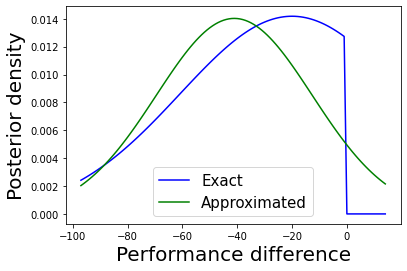

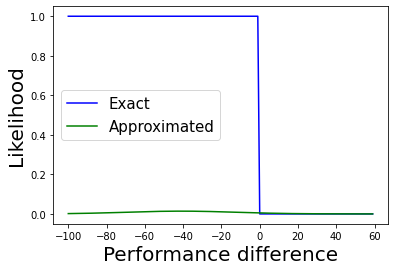

In [4]:
""" This approximation is in fact implicit """
epFJ.plot_posterior_approximation()

""" Not truly illuminating graphics """
epFJ.plot_likelihood_approximation()


## Updating the ratings
Uncomment to update the ratings. Leave uncommented to see how the algorithm continues with three players.

In [5]:
# Jill.likelihood_skill = Jill.likelihood_perf + Player.luck
# Fred.likelihood_skill = Fred.likelihood_perf + Player.luck
# print("Fred's approximated skill likelihood is equal to the density of a", Fred.likelihood_skill)
# print("Jill's approximated skill likelihood is equal to the density of a", Jill.likelihood_skill)
# Jill.skill = Jill.skill.density_mult(Jill.likelihood_skill)
# Fred.skill = Fred.skill.density_mult(Fred.likelihood_skill)
# print("Fred's new rating is", Fred.skill)
# print("Jill's new rating is", Jill.skill)

## Three players game
We consider the same parameters and the same outcome but with a 
a third player, Steve, who joins the game and places third if Jill has won, first if she has lost.
This translates into two results: the first is between Jill and Fred, the second between Fred and Steve.

In [6]:
Steve = Player("Fred", rating_mu=140, rating_sigma2=1600)
Fred_wins = Jill_wins  # in this example Fred always get the second place

""" As before """
Steve.perf = Steve.skill + Player.luck
print("Steve skill follows a", Steve.skill, "and his performance a", Steve.perf)

""" We rename the previous likelihood of Fred perf and we calculate its posterior after the previous result """
Fred.likelihood_perfFJ = Fred.likelihood_perf
Fred.perf_post = Fred.perf.density_mult(Fred.likelihood_perfFJ)
print("Propagating the previous likelihood we update Fred's performance, now a", Fred.perf_post)

""" We repeat expectation propagation """
prior_deltaSF = Steve.perf - Fred.perf_post
epSF = ExpectationPropagation(second_player_wins=Fred_wins)
epSF.approximate(context=prior_deltaSF)
likelihoodSF = epSF.approximated_likelihood
print("We have a second likelihood update for Fred")
Fred.likelihood_perfSF = Steve.perf - likelihoodSF
print("Fred's new likelihood performance is a", Fred.likelihood_perfSF)

""" We replace the posterior after the first result with the posterior after the second result """
Fred.perf_post = Fred.perf.density_mult(Fred.likelihood_perfSF)
print("Propagating the previous likelihood we update Fred's performance, now a", Fred.perf_post)

""" We repeat the process with Jill and back with Steve (2 times is more than sufficient) """
for _ in range(2):
    prior_deltaFJ = Fred.perf_post - Jill.perf
    epFJ.approximate(context=prior_deltaFJ)
    likelihoodFJ = epFJ.approximated_likelihood
    Fred.likelihood_perfFJ = Jill.perf + likelihoodFJ
    Fred.perf_post = Fred.perf.density_mult(Fred.likelihood_perfFJ)
    prior_deltaSF = Steve.perf - Fred.perf_post
    epSF.approximate(context=prior_deltaSF)
    likelihoodSF = epSF.approximated_likelihood
    Fred.likelihood_perfSF = Steve.perf - likelihoodSF
    Fred.perf_post = Fred.perf.density_mult(Fred.likelihood_perfSF)

print("The likelihood of the game between Fred and Jill now is", likelihoodFJ)
print("The likelihood of the game between Steve and Fred now is", likelihoodSF)



Steve skill follows a Gaussian with mean 140.0 and variance 1600.0 and his performance a Gaussian with mean 140.0 and variance 1625.0
Propagating the previous likelihood we update Fred's performance, now a Gaussian with mean 99.4 and variance 49.2
We have a second likelihood update for Fred
Fred's new likelihood performance is a Gaussian with mean 177.1 and variance 2043.4
Propagating the previous likelihood we update Fred's performance, now a Gaussian with mean 101.8 and variance 48.8
The likelihood of the game between Fred and Jill now is Gaussian with mean -59.8 and variance 1490.9
The likelihood of the game between Steve and Fred now is Gaussian with mean -37.1 and variance 418.4


## Updating the ratings
Now, with three players.

In [7]:
""" Jill' rating is updated using the posterior distribution of Fred's perfomance after the second result"""
Jill.likelihood_perf = Fred.perf_post - likelihoodFJ
print("Jill's approximated perf likelihood is equal to the density of a", Jill.likelihood_perf)

""" Steve' rating is updated using the posterior distribution of Fred's perfomance after the first result"""
Fred.perf_post = Fred.perf.density_mult(Fred.likelihood_perfFJ)
Steve.likelihood_perf = Fred.perf_post + likelihoodSF
print("Steve's approximated perf likelihood is equal to the density of a", Steve.likelihood_perf)

""" Fred's rating is updated using both likelihoods as message to multiply"""
Fred.likelihood_perf = Fred.likelihood_perfFJ.density_mult(Fred.likelihood_perfSF)
print("Fred's approximated perf likelihood is equal to the density of a", Fred.likelihood_perf)

""" Let's update all the ratings """
Jill.likelihood_skill = Jill.likelihood_perf + Player.luck
print("Jill's approximated skill likelihood is equal to the density of a", Jill.likelihood_skill)
Fred.likelihood_skill = Fred.likelihood_perf + Player.luck
print("Fred's approximated skill likelihood is equal to the density of a", Fred.likelihood_skill)
Steve.likelihood_skill = Steve.likelihood_perf + Player.luck
print("Steve's approximated skill likelihood is equal to the density of a", Steve.likelihood_skill)
Jill.skill = Jill.skill.density_mult(Jill.likelihood_skill)
print("Jill's new rating is", Jill.skill)
Fred.skill = Fred.skill.density_mult(Fred.likelihood_skill)
print("Fred's new rating is", Fred.skill)
Steve.skill = Steve.skill.density_mult(Steve.likelihood_skill)
print("Steve's new rating is", Steve.skill)

Jill's approximated perf likelihood is equal to the density of a Gaussian with mean 161.6 and variance 1539.7
Steve's approximated perf likelihood is equal to the density of a Gaussian with mean 62.3 and variance 467.6
Fred's approximated perf likelihood is equal to the density of a Gaussian with mean 130.8 and variance 1234.1
Jill's approximated skill likelihood is equal to the density of a Gaussian with mean 161.6 and variance 1564.7
Fred's approximated skill likelihood is equal to the density of a Gaussian with mean 130.8 and variance 1259.1
Steve's approximated skill likelihood is equal to the density of a Gaussian with mean 62.3 and variance 492.6
Jill's new rating is Gaussian with mean 141.1 and variance 791.1
Fred's new rating is Gaussian with mean 100.6 and variance 24.5
Steve's new rating is Gaussian with mean 80.6 and variance 376.6
